## Homework 10

In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.

### Step 1
Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class?

### Step 2
Run the training with one single neuron (as we did in the lecture). What accuracy can you achieve?

### Step 3
Make further modifications to improve the accuracy (e.g. add more neurons, more layers, etc.). What is the maximum accuracy you can achieve?



### Day-Night Image Classification

In this notebook, we will implement a DNN classifier to classify images taken by stationary cameras as day or night images. We will also establish a baseline to make sure our deep learning implementation outperforms a simple hand-picked feature-based classification.

In [24]:
import cv2
import joblib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential, layers, losses, metrics, optimizers, activations, callbacks

In [2]:
plt.rcParams['figure.figsize'] = [15, 6]
sns.set_style('whitegrid')

#### Dataset Loading

We will use the day-night image dataset that you can download from [here](https://www.kaggle.com/datasets/stevemark/daynight-dataset?resource=download).

In [3]:
data = joblib.load('data/day_night_dataset.pckl')
fnames = data['images']
hours = data['hours']

#### Dataset Visualization

Let'sw now visualize some random data and the corresponding labels to see what we are dealing with here.

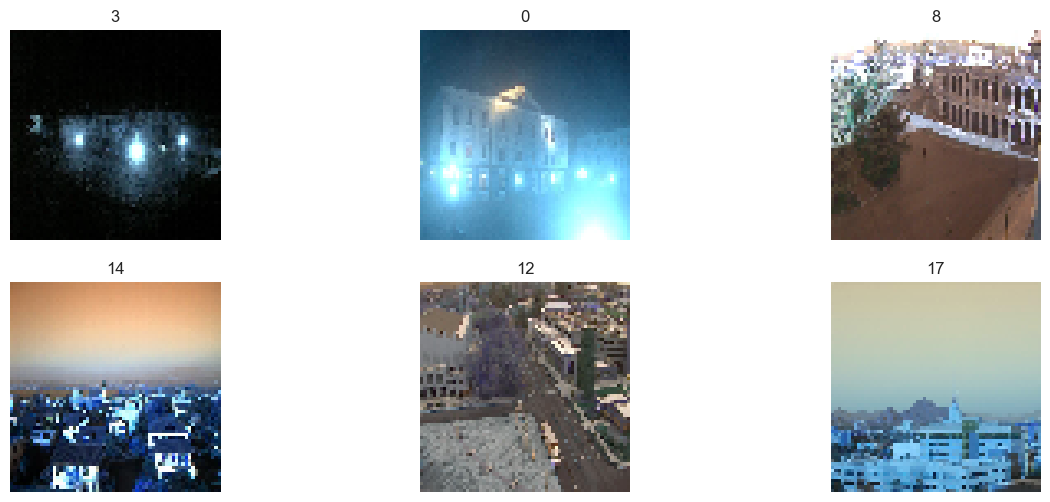

In [4]:
for cnt, idx in enumerate(np.random.randint(0, len(fnames), 6)):
    plt.subplot(2, 3, cnt + 1), plt.imshow(cv2.cvtColor(fnames[idx], cv2.COLOR_BGR2RGB))
    plt.title(hours[idx]), plt.axis(False)

#### Data Preprocessing

Now we will prepare the data for the training. That means that we load all the images, downsample them to a more treatable size and prepare the binary annotations.

In [5]:
size = 64

images = list(map(lambda i: cv2.resize(i, (size, size)), fnames))
images = np.array(images)/255
labels = hours

images.shape, labels.shape

((1722, 64, 64, 3), (1722,))

In [6]:
# Divide the data into day and night images
labels = np.array([1 if (l <= 6 or l >= 18) else 0 for l in labels])

# Are the two classes balanced?
print('Num day images:  ', np.sum(labels == 0))
print('Num night images:', np.sum(labels == 1))

Num day images:   786
Num night images: 936


Let's now shuffle the data and visualize them one last time.

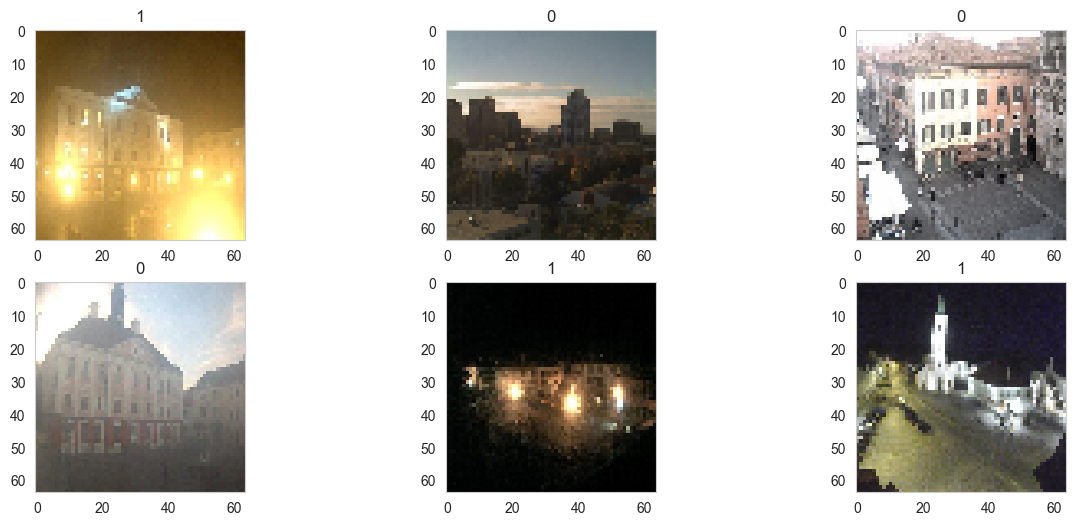

In [17]:
images, labels = shuffle(images, labels)
for cnt, idx in enumerate(np.random.randint(0, len(images), 6)):
    plt.subplot(2, 3, cnt + 1), plt.imshow(images[idx]), plt.title(labels[idx]), plt.grid(False)

#### Build the Baseline

Before we start training our neural network based model, we might need to establish a performance baseline. We do so to be able to tell whether the model is actually good or not.

Since we are dealing with a day-night problem, the most straightforward approach is to use the mean color (or even luminance) to classify images as day vs night. So let's do it :-)

(<matplotlib.legend.Legend at 0x1c9d0909400>,
 Text(0.5, 0, 'average color'),
 None)

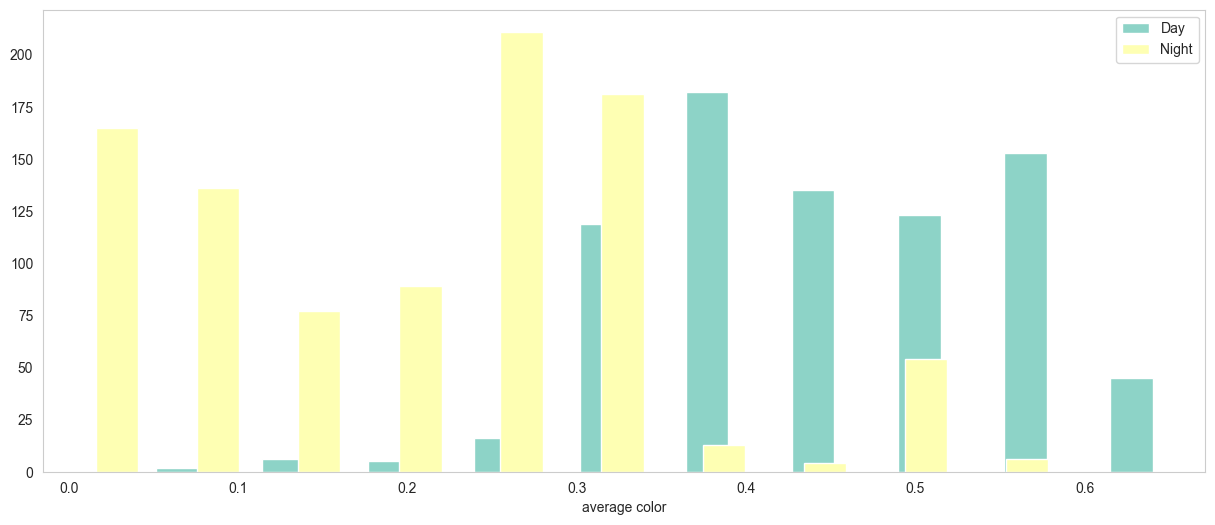

In [8]:
# Compute mean color values for each image
mu_day = [np.mean(i) for i, l in zip(images, labels) if l == 0]
mu_night = [np.mean(i) for i, l in zip(images, labels) if l == 1]

# Visualize the histograms of the obtained mean colors. Are they well separated?
counts_day, bins_day = np.histogram(mu_day, bins=10)
counts_night, bins_night = np.histogram(mu_night, bins=10)

plt.bar(bins_day[0:-1], counts_day, width=0.025)
plt.bar(bins_night[0:-1], counts_night, width=0.025)
plt.legend(['Day', 'Night']), plt.xlabel('average color'), plt.grid(False)

The histograms do not seem that well separated. Anyway, let's find the optimal threshold that maximizes the classification accuracy.

(Text(0.5, 0, 'threshold'), Text(0, 0.5, 'accuracy'))

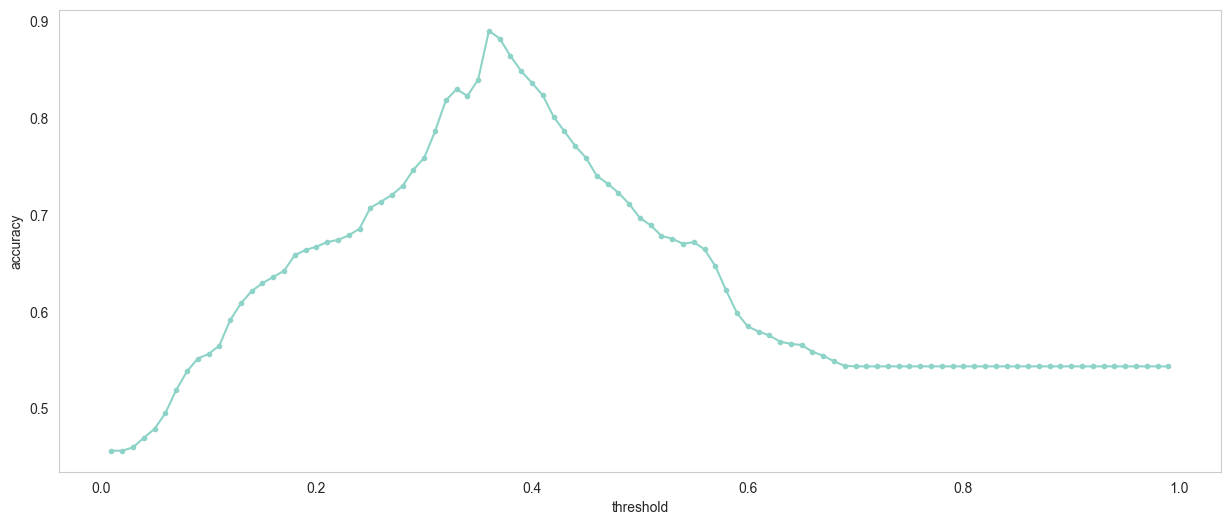

In [9]:
acc = []
thresholds = np.arange(0.01, 1, 0.01)

for th in thresholds:
    acc.append((np.sum(mu_day >= th) + np.sum(mu_night < th)) / len(labels))
    
plt.plot(thresholds, acc, '.-'), plt.grid(False)
plt.xlabel('threshold'), plt.ylabel('accuracy')

#### Binary Classifier Based on Neural Networks

Let's now build a NN-based classifier and let's see if we can beat the baseline.

In [25]:
model = Sequential([
    layers.Input(shape=(size, size, 3)),
    layers.Flatten(),
    layers.Dense(16, activation=activations.leaky_relu),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.Dense(1, activation=activations.sigmoid),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │       196,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,705 (768.38 KB)

 Trainable params: 196,673 (768.25 KB)

 Non-trainable params: 32 (128.00 B)

Let's compile the model and start training.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.3, random_state=42, shuffle=True)

In [27]:
epochs = 100
batch_size = 32

model.compile(loss=losses.Huber(),
              optimizer=optimizers.Adam(learning_rate=0.001),
              metrics=[metrics.binary_accuracy,
                       metrics.MSE])

history = model.fit(X_train,
                    y_train,
                    batch_size=batch_size,
                    validation_data=(X_test, y_test),
                    epochs=epochs,
                    callbacks=[callbacks.EarlyStopping(patience=5,
                                                       monitor='val_loss',
                                                       restore_best_weights=True)]
                    )

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - binary_accuracy: 0.9245 - loss: 0.0304 - mean_squared_error: 0.0607 - val_binary_accuracy: 0.7621 - val_loss: 0.0771 - val_mean_squared_error: 0.1543
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.9494 - loss: 0.0235 - mean_squared_error: 0.0471 - val_binary_accuracy: 0.9439 - val_loss: 0.0267 - val_mean_squared_error: 0.0534
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.9502 - loss: 0.0229 - mean_squared_error: 0.0458 - val_binary_accuracy: 0.9400 - val_loss: 0.0279 - val_mean_squared_error: 0.0558
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.9593 - loss: 0.0197 - mean_squared_error: 0.0394 - val_binary_accuracy: 0.9594 - val_loss: 0.0178 - val_mean_squared_error: 0.0356
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.9577 - loss: 0.0188 - mean_squared_error: 0.0377 - val_binary_accuracy: 0.9594 - val_loss: 0.0180 - val_mean_square

(<Axes: title={'center': 'accuracy'}, xlabel='epoch'>,
 None,
 Text(0.5, 0, 'epoch'),
 Text(0.5, 1.0, 'accuracy'))

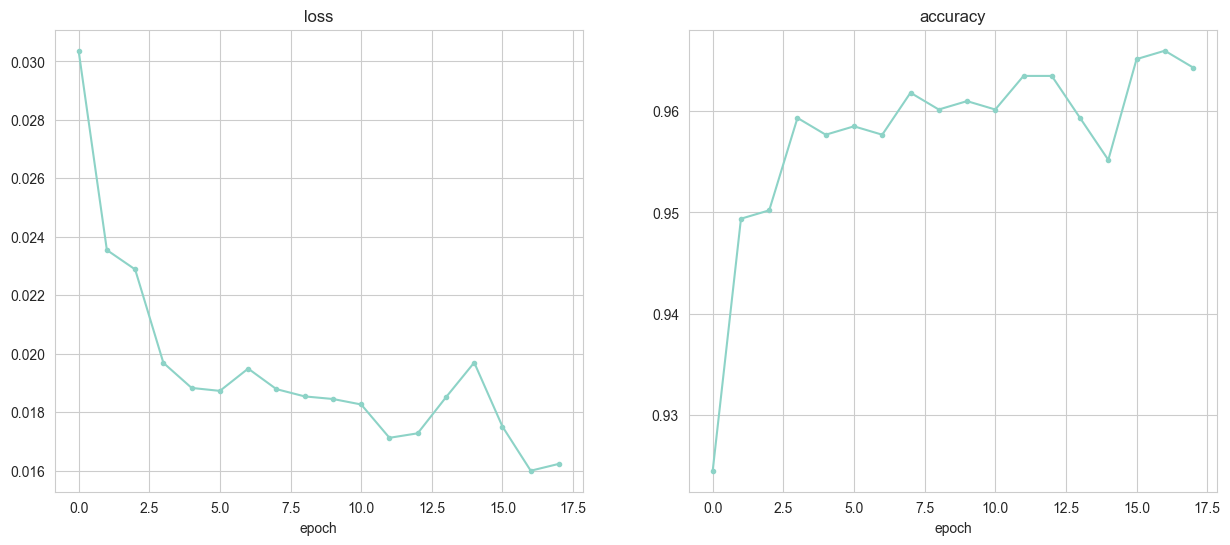

In [28]:
h = history.history
epochs = range(len(h['loss']))

plt.subplot(121), plt.plot(epochs, h['loss'], '.-'), plt.grid(True), plt.xlabel('epoch'), plt.title('loss')
plt.subplot(122), plt.plot(epochs, h['binary_accuracy'], '.-'), plt.grid(True), plt.xlabel('epoch'), plt.title('accuracy')

In [29]:
y_true = labels.flatten()
y_pred = model.predict(images).flatten()

y_pred_ = y_pred > 0.5

# Overall accuracy
num_samples = len(y_true)
acc = np.sum(y_true == y_pred_)/num_samples

# Accuracy for digit 0
mask = y_true == 0
acc0 = np.sum(y_true[mask] == y_pred_[mask])/np.sum(mask)

# Accuracy for digit 1
mask = y_true == 1
acc1 = np.sum(y_true[mask] == y_pred_[mask])/np.sum(mask)

print('Overall acc', acc)
print('Digit-0 acc', acc0)
print('Digit-1 acc', acc1)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Overall acc 0.9639953542392566
Digit-0 acc 0.9567430025445293
Digit-1 acc 0.9700854700854701


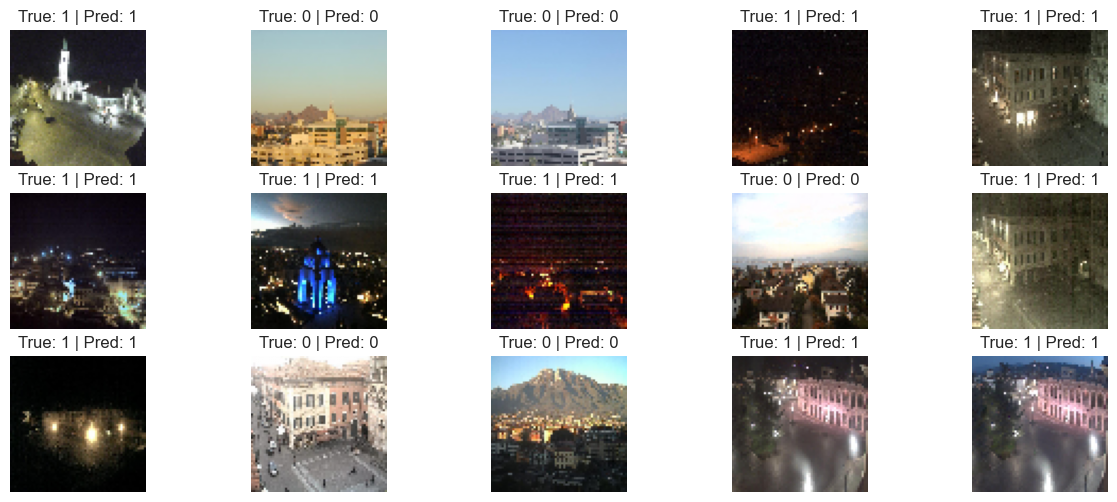

In [30]:
# Visualisation
for ii in range(15):
    idx = np.random.randint(0, len(y_pred))
    plt.subplot(3,5,ii+1), plt.imshow(images[idx, ...]), plt.axis(False)
    plt.title('True: ' + str(y_true[idx]) + ' | Pred: ' + str(int(y_pred_[idx])))